# 07 — Seleção de Modelo com Calibração Unificada

Carrega os `best_params` exportados pelos notebooks 01–06 e aplica
`CalibratedClassifierCV(method='isotonic', cv=3)` de forma consistente para todos.

**Por que calibrar aqui e não nos notebooks AG?**  
Os notebooks AG avaliam modelos *sem calibração* para maximizar velocidade do CV.
O modelo de produção da Fase 1 (`best_model_calibrated.pkl`) foi construído *com*
calibração — portanto a validação clínica deve usar probabilidades calibradas.
Isso evita rejeitar modelos válidos (e.g., 03 Exp1: recall uncalibrated=0.787 → calibrated=0.821).

**Validação clínica (mesma lógica dos notebooks AG):**
- `recall >= 0.80` (piso absoluto)
- `FN growth <= 30%` vs baseline Fase 1
- `FP growth <= 15%` vs baseline Fase 1

In [11]:
import sys
sys.path.insert(0, '..')

import gc
import json
import math
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    recall_score, fbeta_score, f1_score,
    precision_score, roc_auc_score,
)
from sklearn.utils.class_weight import compute_sample_weight
from utils.experiment_utils import apply_scenario

RANDOM_STATE          = 42
OPERATIONAL_THRESHOLD = 0.40
DATA_DIR              = pathlib.Path('../data')
METRICS_DIR           = pathlib.Path('../results/metrics')
PARAMS_DIR            = pathlib.Path('../results/params')
FIGURES_DIR           = pathlib.Path('../results/figures')

print('Setup OK')

Setup OK


## 1. Dados — Cenário B (mesma split dos notebooks AG)

In [12]:
X_train_full = pd.read_parquet(DATA_DIR / 'X_train.parquet')
X_test_full  = pd.read_parquet(DATA_DIR / 'X_test.parquet')
y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet').iloc[:, 0]
y_test  = pd.read_parquet(DATA_DIR / 'y_test.parquet').iloc[:, 0]

X_train = apply_scenario(X_train_full, 'B')
X_test  = apply_scenario(X_test_full,  'B')

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'Prematuros treino : {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Prematuros teste  : {y_test.sum():,} ({y_test.mean():.1%})')

X_train: (552344, 29)  |  X_test: (138087, 29)
Prematuros treino : 56,346 (10.2%)
Prematuros teste  : 14,086 (10.2%)


## 2. Baseline Fase 1 (referência para validação clínica)

In [13]:
with open(METRICS_DIR / 'best_model_operational_metrics.json') as f:
    _bl = json.load(f)

BASELINE_PARAMS = _bl['best_params']
bl_metrics      = _bl['metrics']

# FN e FP do modelo de produção calibrado (Fase 1)
BL_FN = int(bl_metrics['fn'])
BL_FP = int(bl_metrics['fp'])

print(f'Baseline Fase 1 (calibrado):')
print(f'  recall : {bl_metrics["recall"]:.4f}')
print(f'  f2     : {bl_metrics["f2"]:.4f}')
print(f'  FN     : {BL_FN:,}')
print(f'  FP     : {BL_FP:,}')

Baseline Fase 1 (calibrado):
  recall : 0.8135
  f2     : 0.3823
  FN     : 2,627
  FP     : 82,083


## 3. Funções de avaliação calibrada

In [14]:
def load_scenario_data(scenario: str) -> tuple:
    X_tr = apply_scenario(X_train_full, scenario)
    X_te = apply_scenario(X_test_full,  scenario)
    return X_tr, X_te, y_train, y_test


def compute_metrics(y_true, y_prob, threshold=OPERATIONAL_THRESHOLD):
    y_pred = (y_prob >= threshold).astype(int)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    return {
        'threshold': float(threshold),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f2':        fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_prob),
        'TP': tp, 'FN': fn, 'FP': fp,
    }


def evaluate_calibrated_histgb(params, threshold=OPERATIONAL_THRESHOLD,
                                X_tr=None, X_te=None, y_tr=None, y_te=None):
    X_tr = X_tr if X_tr is not None else X_train
    X_te = X_te if X_te is not None else X_test
    y_tr = y_tr if y_tr is not None else y_train
    y_te = y_te if y_te is not None else y_test
    sw   = compute_sample_weight(class_weight='balanced', y=y_tr)
    base = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    cal  = CalibratedClassifierCV(base, method='isotonic', cv=3)
    cal.fit(X_tr, y_tr, sample_weight=sw)
    y_prob = cal.predict_proba(X_te)[:, 1]
    return compute_metrics(y_te, y_prob, threshold=threshold)


def evaluate_calibrated_rf(params, threshold=OPERATIONAL_THRESHOLD,
                            X_tr=None, X_te=None, y_tr=None, y_te=None):
    X_tr = X_tr if X_tr is not None else X_train
    X_te = X_te if X_te is not None else X_test
    y_tr = y_tr if y_tr is not None else y_train
    y_te = y_te if y_te is not None else y_test
    base = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    cal  = CalibratedClassifierCV(base, method='isotonic', cv=3)
    cal.fit(X_tr, y_tr)
    y_prob = cal.predict_proba(X_te)[:, 1]
    return compute_metrics(y_te, y_prob, threshold=threshold)


print('Funções de avaliação calibrada definidas.')

Funções de avaliação calibrada definidas.


## 4. Baseline calibrado (re-avaliado aqui para consistência)

Serve como ponto de referência: o que `best_model_calibrated.pkl` produziria se treinado
com os dados atuais (mesma split, mesma calibração).

In [15]:
baseline_eval = evaluate_calibrated_histgb(BASELINE_PARAMS)
print('=== Baseline Fase 1 (calibrado, re-avaliado) ===')
for k, v in baseline_eval.items():
    print(f'  {k:10s}: {v}')

=== Baseline Fase 1 (calibrado, re-avaliado) ===
  threshold : 0.4
  recall    : 0.8088172653698708
  f2        : 0.3829322398494219
  f1        : 0.21394903382096112
  precision : 0.12327951869806095
  roc_auc   : 0.6525423136842401
  TP        : 11393
  FN        : 2693
  FP        : 81023


## 5. Carregar params dos experimentos AG e avaliar com calibração

In [16]:
rows = [{
    'notebook':   'BASELINE',
    'experiment': 'Fase1_RandomizedSearch',
    'model_type': 'histgb',
    'scenario':   'B',
    'cv_fitness': None,
    **baseline_eval,
}]

skipped = []

for path in sorted(PARAMS_DIR.glob('*.json')):
    with open(path) as f:
        entry = json.load(f)

    nb         = entry['notebook']
    exp        = entry['experiment']
    model_type = entry.get('model_type', 'histgb')
    params     = entry['best_params']
    threshold  = entry.get('best_threshold', OPERATIONAL_THRESHOLD)
    scenario   = entry.get('scenario', 'B')

    print(f'Avaliando {nb} / {exp} [cenário {scenario}, thr={threshold}]...')

    if model_type == 'smote_histgb':
        skipped.append({'notebook': nb, 'experiment': exp,
                        'motivo': 'SMOTE colapsa recall — REPROVADO por razão fundamental'})
        print(f'  Pulado: SMOTE')
        continue

    X_tr, X_te, y_tr, y_te = load_scenario_data(scenario)

    try:
        if model_type == 'rf':
            metrics = evaluate_calibrated_rf(params, threshold, X_tr, X_te, y_tr, y_te)
        else:
            metrics = evaluate_calibrated_histgb(params, threshold, X_tr, X_te, y_tr, y_te)
    except Exception as e:
        print(f'  ERRO: {e}')
        continue

    rows.append({
        'notebook':   nb,
        'experiment': exp,
        'model_type': model_type,
        'scenario':   scenario,
        'cv_fitness': entry.get('cv_fitness'),
        **metrics,
    })
    print(f'  recall={metrics["recall"]:.4f}  f2={metrics["f2"]:.4f}  FN={metrics["FN"]:,}  FP={metrics["FP"]:,}')
    gc.collect()

df = pd.DataFrame(rows)
print(f'\nTotal avaliados: {len(df)}  |  Pulados (SMOTE): {len(skipped)}')

Avaliando 01_AG / Exp1_conservador [cenário B, thr=0.4]...
  recall=0.8107  f2=0.3817  FN=2,666  FP=81,849
Avaliando 01_AG / Exp2_padrao [cenário B, thr=0.4]...
  recall=0.8171  f2=0.3820  FN=2,576  FP=82,804
Avaliando 01_AG / Exp3_exploratorio [cenário B, thr=0.4]...
  recall=0.8128  f2=0.3817  FN=2,637  FP=82,190
Avaliando 02_AG_threshold040 / Exp1_conservador [cenário B, thr=0.4]...
  recall=0.8107  f2=0.3817  FN=2,666  FP=81,849
Avaliando 02_AG_threshold040 / Exp2_padrao [cenário B, thr=0.4]...
  recall=0.8171  f2=0.3820  FN=2,576  FP=82,804
Avaliando 02_AG_threshold040 / Exp3_exploratorio [cenário B, thr=0.4]...
  recall=0.8128  f2=0.3817  FN=2,637  FP=82,190
Avaliando 02_AG_threshold040 / Exp4_hotstart [cenário B, thr=0.4]...
  recall=0.8171  f2=0.3820  FN=2,576  FP=82,804
Avaliando 03_AG_expanded_search / Exp1_conservador [cenário B, thr=0.4]...
  recall=0.8229  f2=0.3809  FN=2,494  FP=84,233
Avaliando 03_AG_expanded_search / Exp2_padrao [cenário B, thr=0.4]...
  recall=0.8302  

## 6. Validação clínica — APROVADO / REPROVADO

In [17]:
MAX_FP_GROWTH_PCT = 0.15
MAX_FN_GROWTH_PCT = 0.30
MIN_RECALL_TEST   = 0.80

def validate(row):
    if row['experiment'] == 'Fase1_RandomizedSearch':
        return 'BASELINE'
    recall_ok = row['recall'] >= MIN_RECALL_TEST
    fn_growth = (row['FN'] - BL_FN) / max(BL_FN, 1)
    fp_growth = (row['FP'] - BL_FP) / max(BL_FP, 1)
    fn_ok = fn_growth <= MAX_FN_GROWTH_PCT
    fp_ok = fp_growth <= MAX_FP_GROWTH_PCT
    return 'APROVADO' if (recall_ok and fn_ok and fp_ok) else 'REPROVADO'

df['status'] = df.apply(validate, axis=1)
df['fn_delta_pct'] = ((df['FN'] - BL_FN) / max(BL_FN, 1) * 100).round(1)
df['fp_delta_pct'] = ((df['FP'] - BL_FP) / max(BL_FP, 1) * 100).round(1)

display_cols = ['notebook', 'experiment', 'model_type', 'recall', 'f2', 'FN', 'FP',
                'fn_delta_pct', 'fp_delta_pct', 'status']

print('=== Comparação Calibrada — todos os experimentos AG ===')
display(df[display_cols].round({'recall': 4, 'f2': 4}))

if skipped:
    print('\nExperimentos pulados (SMOTE):')
    for s in skipped:
        print(f'  {s["notebook"]} / {s["experiment"]}: {s["motivo"]}')

=== Comparação Calibrada — todos os experimentos AG ===


,notebook,experiment,model_type,recall,f2,FN,FP,fn_delta_pct,fp_delta_pct,status
0,BASELINE,Fase1_RandomizedSearch,histgb,0.8088,0.3829,2693,81023,2.5,-1.3,BASELINE
1,01_AG,Exp1_conservador,histgb,0.8107,0.3817,2666,81849,1.5,-0.3,APROVADO
2,01_AG,Exp2_padrao,histgb,0.8171,0.3820,2576,82804,-1.9,0.9,APROVADO
3,01_AG,Exp3_exploratorio,histgb,0.8128,0.3817,2637,82190,0.4,0.1,APROVADO
4,02_AG_threshold040,Exp1_conservador,histgb,0.8107,0.3817,2666,81849,1.5,-0.3,APROVADO
5,02_AG_threshold040,Exp2_padrao,histgb,0.8171,0.3820,2576,82804,-1.9,0.9,APROVADO
6,02_AG_threshold040,Exp3_exploratorio,histgb,0.8128,0.3817,2637,82190,0.4,0.1,APROVADO
7,02_AG_threshold040,Exp4_hotstart,histgb,0.8171,0.3820,2576,82804,-1.9,0.9,APROVADO
8,03_AG_expanded_search,Exp1_conservador,histgb,0.8229,0.3809,2494,84233,-5.1,2.6,APROVADO
9,03_AG_expanded_search,Exp2_padrao,histgb,0.8302,0.3800,2392,85824,-8.9,4.6,APROVADO



Experimentos pulados (SMOTE):
  04_AG_smote / Exp1_SMOTE_k5_padrao: SMOTE colapsa recall — REPROVADO por razão fundamental
  04_AG_smote / Exp2_SMOTE_k5_hotstart: SMOTE colapsa recall — REPROVADO por razão fundamental
  04_AG_smote / Exp3_SMOTE_k10_padrao: SMOTE colapsa recall — REPROVADO por razão fundamental
  04_AG_smote / Exp4_BorderlineSMOTE_padrao: SMOTE colapsa recall — REPROVADO por razão fundamental


## Análise de descarte — Random Forest, Co-evolução e SMOTE

### Random Forest (NB05)

O AG otimizou o RF e encontrou recall ≈ 1.0 no conjunto de teste **sem calibração**.
Porém, o modelo falha em ambos os cenários de avaliação:

| cenário | recall | FP | motivo do descarte |
|---|---|---|---|
| sem calibração (NB05, threshold 0.40) | ~1.0 | ~125.000 | FP cresce +54% vs baseline (limite: 15%) |
| com calibração isotônica (NB07) | ~0.02 | ~314 | modelo para de prever prematuros |

A calibração isotônica destrói o RF porque `max_depth=5` produz pouquíssimos valores
distintos de probabilidade — o calibrador redistribui tudo para abaixo de 0.40.
O modelo é instável: ou sinaliza quase todo mundo (sem calibração) ou quase ninguém
(com calibração). **RF descartado.**

### Co-evolução (NB06)

O AG co-evoluiu hiperparâmetros e threshold simultaneamente. Os thresholds escolhidos
(0.45–0.50) resultam em recall < 0.80 no teste com calibração — todos REPROVADOS.
O HistGB subjacente não é mais discriminativo que os experimentos 01–03 com threshold
fixo em 0.40. **Co-evolução descartada; threshold operacional permanece em 0.40.**

### SMOTE (NB04)

SMOTE colapsa o recall para ~0.06–0.11 no teste — o modelo aprende a classificar as
amostras sintéticas geradas pelo SMOTE, mas não generaliza para dados reais.
**SMOTE descartado.**

## 7. Melhor modelo APROVADO

In [18]:
aprovados = df[df['status'] == 'APROVADO'].copy()

if aprovados.empty:
    print('Nenhum experimento APROVADO — usar baseline Fase 1.')
else:
    # Ordena por: menor FN primeiro (prioridade clínica), depois maior F2
    best = aprovados.sort_values(['FN', 'f2'], ascending=[True, False]).iloc[0]

    print('=== MELHOR MODELO APROVADO ===')
    print(f'  Notebook   : {best["notebook"]}')
    print(f'  Experimento: {best["experiment"]}')
    print(f'  Tipo       : {best["model_type"]}')
    print(f'  recall     : {best["recall"]:.4f}')
    print(f'  f2         : {best["f2"]:.4f}')
    print(f'  FN         : {best["FN"]:,}  (baseline: {BL_FN:,} | delta: {best["FN"]-BL_FN:+,})')
    print(f'  FP         : {best["FP"]:,}  (baseline: {BL_FP:,} | delta: {best["FP"]-BL_FP:+,})')

    # Carrega os params do JSON correspondente
    prefix = best['notebook'][:2]  # ex: '03'
    param_file = PARAMS_DIR / f'{prefix}_{best["experiment"]}.json'
    if param_file.exists():
        with open(param_file) as f:
            best_entry = json.load(f)
        print(f'\n  Params     : {best_entry["best_params"]}')
        threshold_used = best_entry.get('best_threshold', OPERATIONAL_THRESHOLD)
        print(f'  Threshold  : {threshold_used}')

=== MELHOR MODELO APROVADO ===
  Notebook   : 03_AG_expanded_search
  Experimento: Exp2_padrao
  Tipo       : histgb
  recall     : 0.8302
  f2         : 0.3800
  FN         : 2,392  (baseline: 2,627 | delta: -235)
  FP         : 85,824  (baseline: 82,083 | delta: +3,741)

  Params     : {'max_iter': 100, 'learning_rate': 0.2, 'max_leaf_nodes': 127, 'min_samples_leaf': 20, 'l2_regularization': 0.0, 'max_depth': None, 'max_bins': 255}
  Threshold  : 0.4


## 8. Gráfico comparativo — FN vs F2 (modelos calibrados)

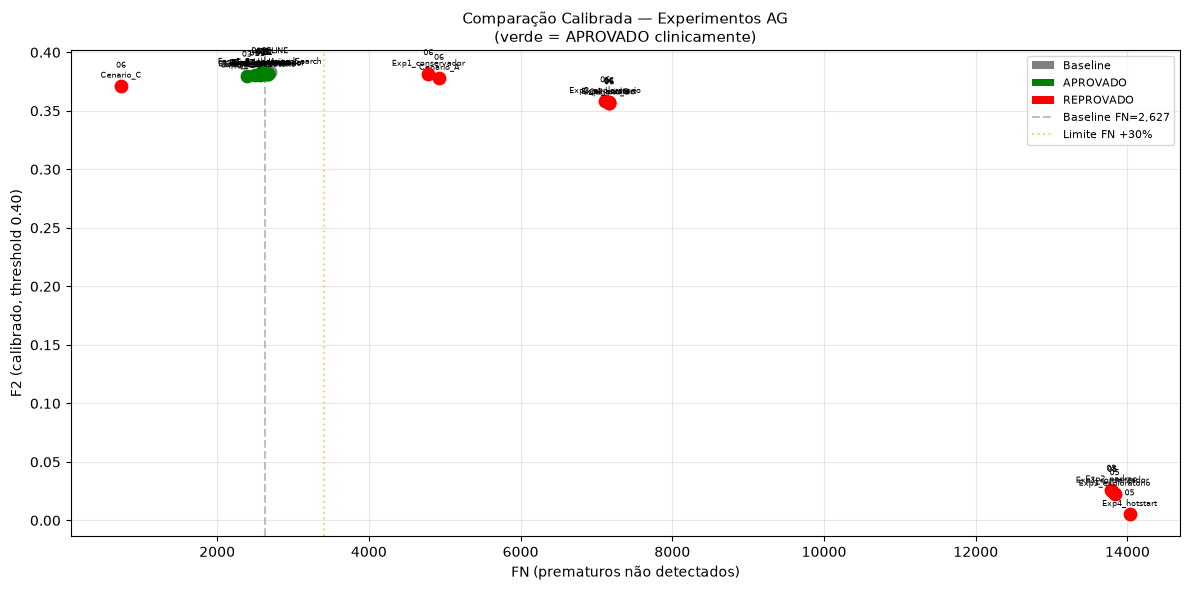

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {'BASELINE': 'gray', 'APROVADO': 'green', 'REPROVADO': 'red'}

for _, row in df.iterrows():
    color = colors.get(row['status'], 'gray')
    label_text = f"{row['notebook'].split('_')[0]}\n{row['experiment']}"
    ax.scatter(row['FN'], row['f2'], color=color, s=80, zorder=3)
    ax.annotate(
        label_text,
        (row['FN'], row['f2']),
        fontsize=6, ha='center', va='bottom',
        xytext=(0, 4), textcoords='offset points',
    )

# Linha de referência baseline
ax.axvline(BL_FN, color='gray', linestyle='--', alpha=0.5, label=f'Baseline FN={BL_FN:,}')
ax.axvline(BL_FN * (1 + 0.30), color='orange', linestyle=':', alpha=0.5, label='Limite FN +30%')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray',  label='Baseline'),
    Patch(facecolor='green', label='APROVADO'),
    Patch(facecolor='red',   label='REPROVADO'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0][-2:], fontsize=8)
ax.set_xlabel('FN (prematuros não detectados)')
ax.set_ylabel('F2 (calibrado, threshold 0.40)')
ax.set_title('Comparação Calibrada — Experimentos AG\n(verde = APROVADO clinicamente)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '07_calibrated_comparison.png', dpi=150)
plt.show()

## 9. Salvar resultados

In [20]:
df.to_csv(METRICS_DIR / '07_calibrated_comparison.csv', index=False)
print(f'Salvo: {METRICS_DIR / "07_calibrated_comparison.csv"}')

# Salva resumo dos APROVADOS
if not aprovados.empty:
    resumo = {
        'best_notebook':   best['notebook'],
        'best_experiment': best['experiment'],
        'best_model_type': best['model_type'],
        'best_metrics': {
            'recall':    round(float(best['recall']), 4),
            'f2':        round(float(best['f2']), 4),
            'precision': round(float(best['precision']), 4),
            'roc_auc':   round(float(best['roc_auc']), 4),
            'fn':        int(best['FN']),
            'fp':        int(best['FP']),
        },
        'baseline_metrics': {
            'fn': BL_FN,
            'fp': BL_FP,
        },
    }
    with open(METRICS_DIR / '07_best_experiment.json', 'w') as f:
        json.dump(resumo, f, indent=2)
    print(f'Salvo: {METRICS_DIR / "07_best_experiment.json"}')

Salvo: ../results/metrics/07_calibrated_comparison.csv
Salvo: ../results/metrics/07_best_experiment.json
